In [2]:
from google.colab import files
uploaded = files.upload()

Saving Global_Superstore2.csv to Global_Superstore2.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# Load dataset
df = pd.read_csv('Global_Superstore2.csv', encoding='latin1')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (51290, 24)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
# Check missing values
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# Check duplicates
print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())

# Check data types
print("\n=== DATA TYPES ===")
print(df.dtypes)

=== MISSING VALUES ===
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0

=== DATA TYPES ===
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market            

In [7]:
# 1. Remove duplicates (already 0, but good practice)
df = df.drop_duplicates()

# 2. Fix Postal Code — fill missing + convert to string
df['Postal Code'] = df['Postal Code'].fillna('Unknown').astype(str)

# 3. Fix date columns — convert from text to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 4. Strip whitespace from text columns
for col in ['Category', 'Region', 'Segment', 'Market', 'Ship Mode', 'Order Priority']:
    df[col] = df[col].str.strip()

# ✅ Confirm
print("✅ Cleaning done! Shape:", df.shape)
print("\nData Types after cleaning:")
print(df[['Order Date', 'Ship Date', 'Postal Code']].dtypes)
print("\nMissing values remaining:", df.isnull().sum().sum())

/tmp/ipykernel_6715/2101917209.py:8: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_6715/2101917209.py:9: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


✅ Cleaning done! Shape: (51290, 24)

Data Types after cleaning:
Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code            object
dtype: object

Missing values remaining: 0


In [8]:
# 1. Fix date format properly (silences the warning)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# 2. Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Sales']).round(4)

# 3. Time columns for trend analysis
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# 4. Shipping days
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 5. Discount category
df['Discount_Category'] = pd.cut(df['Discount'],
    bins=[-0.1, 0.0, 0.2, 0.5, 1.0],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-50%)', 'High (>50%)'])

# ✅ Preview
print("✅ New columns created! Shape:", df.shape)
print("\nNew columns preview:")
df[['Sales', 'Profit', 'Profit_Margin', 'Month_Year', 'Year', 'Ship_Days', 'Discount_Category']].head(8)

✅ New columns created! Shape: (51290, 30)

New columns preview:


,Sales,Profit,Profit_Margin,Month_Year,Year,Ship_Days,Discount_Category
0,2309.650,762.1845,0.3300,2012-07,2012,0,No Discount
1,3709.395,-288.7650,-0.0778,2013-02,2013,2,Low (1-20%)
2,5175.171,919.9710,0.1778,2013-10,2013,1,Low (1-20%)
3,2892.510,-96.5400,-0.0334,2013-01,2013,2,Low (1-20%)
4,2832.960,311.5200,0.1100,2013-11,2013,1,No Discount
5,2862.675,763.2750,0.2666,2013-06,2013,3,Low (1-20%)
6,1822.080,564.8400,0.3100,2011-11,2011,2,No Discount
7,5244.840,996.4800,0.1900,2012-04,2012,4,No Discount


/tmp/ipykernel_6715/2609776144.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6715/2609776144.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('monthly_sales_trend.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


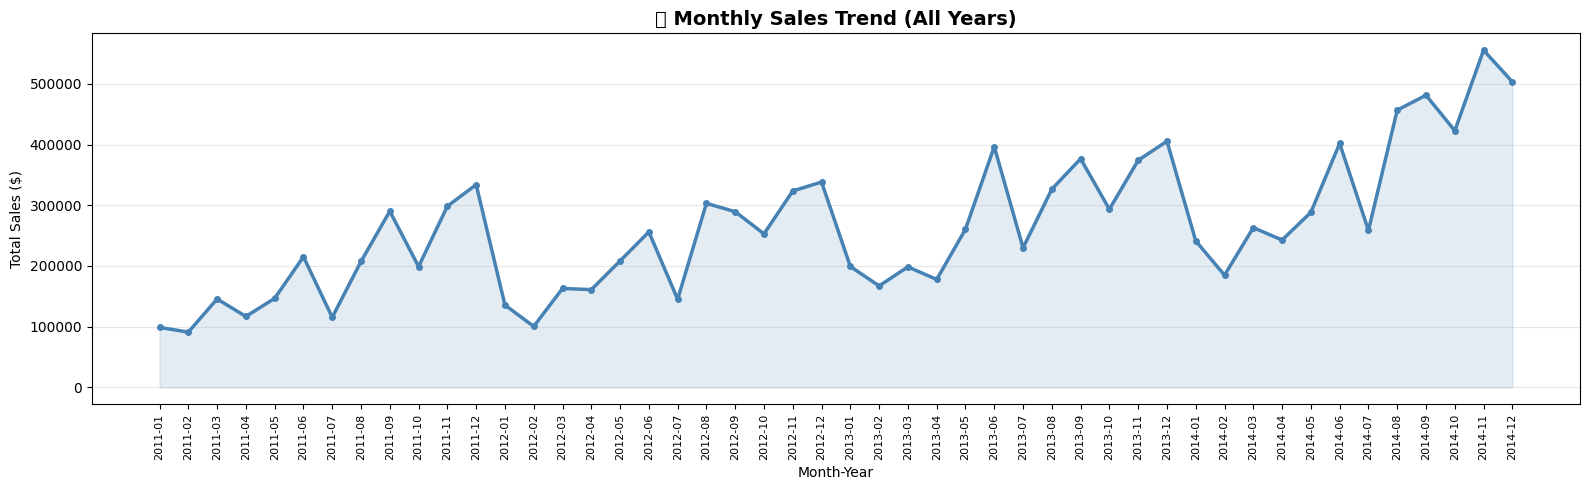

📊 Sales Summary:
Total Revenue: $12,642,502
Best Month: 2014-11 — $555,279
Worst Month: 2011-02 — $91,152


In [9]:
# Monthly Sales Trend
monthly = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly = monthly.sort_values('Month_Year')

plt.figure(figsize=(16, 5))
plt.plot(monthly['Month_Year'], monthly['Sales'],
         color='steelblue', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(range(len(monthly)), monthly['Sales'], alpha=0.15, color='steelblue')
plt.xticks(range(len(monthly)), monthly['Month_Year'], rotation=90, fontsize=8)
plt.title('📈 Monthly Sales Trend (All Years)', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

# Key numbers
print("📊 Sales Summary:")
print(f"Total Revenue: ${monthly['Sales'].sum():,.0f}")
print(f"Best Month: {monthly.loc[monthly['Sales'].idxmax(), 'Month_Year']} — ${monthly['Sales'].max():,.0f}")
print(f"Worst Month: {monthly.loc[monthly['Sales'].idxmin(), 'Month_Year']} — ${monthly['Sales'].min():,.0f}")

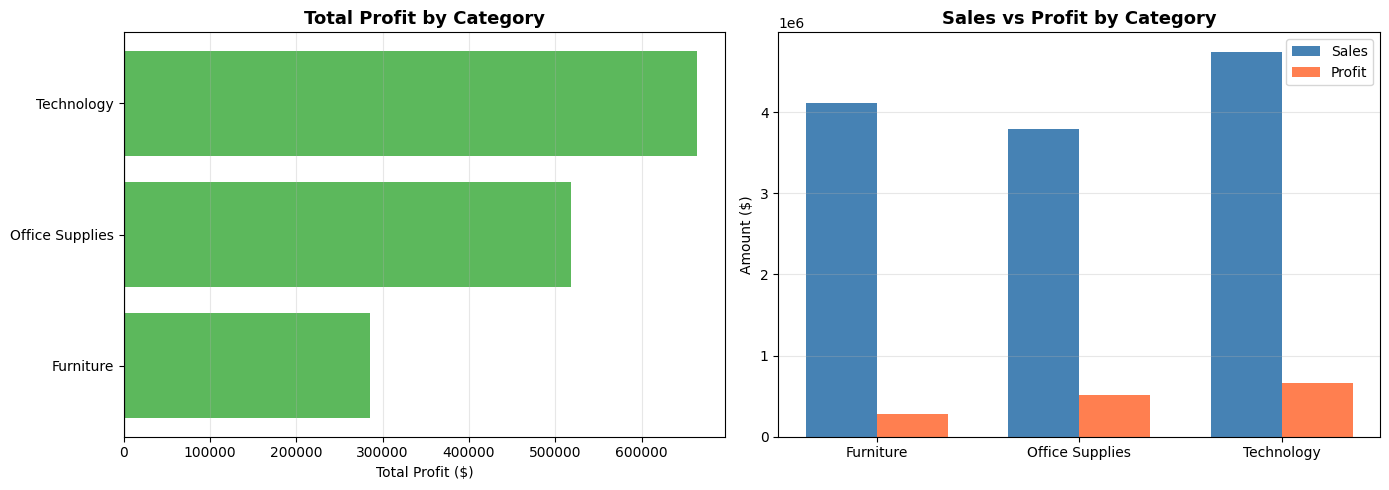

Category Performance:
  Furniture: Sales=$4,110,874 | Profit=$285,205 | Margin=6.9%
  Office Supplies: Sales=$3,787,070 | Profit=$518,474 | Margin=13.7%
  Technology: Sales=$4,744,557 | Profit=$663,779 | Margin=14.0%


In [10]:
# Profit by Category
cat_profit = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat_profit = cat_profit.sort_values('Profit', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Profit by Category
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in cat_profit['Profit']]
axes[0].barh(cat_profit['Category'], cat_profit['Profit'], color=colors)
axes[0].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Chart 2 - Sales vs Profit side by side
x = range(len(cat_profit))
width = 0.35
axes[1].bar([i - width/2 for i in x], cat_profit['Sales'], width, label='Sales', color='steelblue')
axes[1].bar([i + width/2 for i in x], cat_profit['Profit'], width, label='Profit', color='coral')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cat_profit['Category'])
axes[1].set_title('Sales vs Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('profit_by_category.png', dpi=150)
plt.show()

# Key numbers
print("Category Performance:")
for _, row in cat_profit.iterrows():
    margin = (row['Profit']/row['Sales']*100)
    print(f"  {row['Category']}: Sales=${row['Sales']:,.0f} | Profit=${row['Profit']:,.0f} | Margin={margin:.1f}%")

/tmp/ipykernel_6715/650072740.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(region['Region'], rotation=30, ha='right')


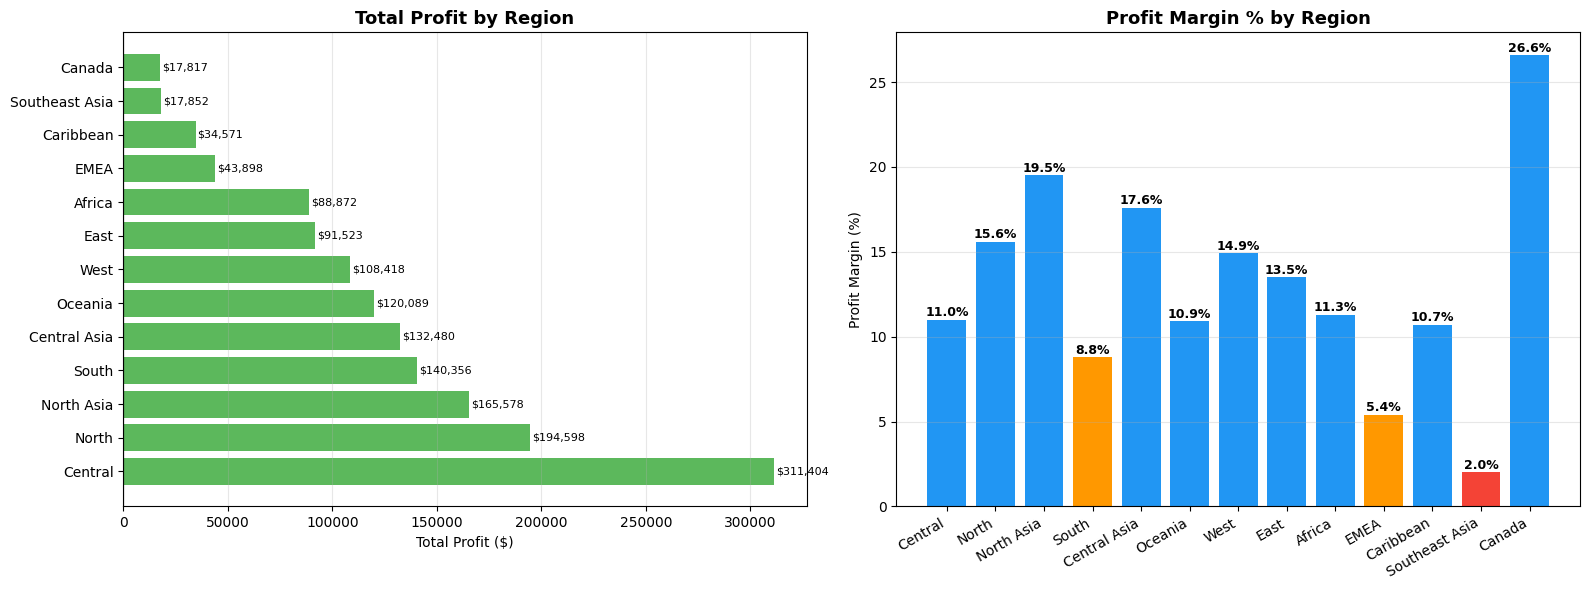

Region Performance:
  Central: Sales=$2,822,303 | Profit=$311,404 | Margin=11.0%
  North: Sales=$1,248,166 | Profit=$194,598 | Margin=15.6%
  North Asia: Sales=$848,310 | Profit=$165,578 | Margin=19.5%
  South: Sales=$1,600,907 | Profit=$140,356 | Margin=8.8%
  Central Asia: Sales=$752,827 | Profit=$132,480 | Margin=17.6%
  Oceania: Sales=$1,100,185 | Profit=$120,089 | Margin=10.9%
  West: Sales=$725,458 | Profit=$108,418 | Margin=14.9%
  East: Sales=$678,781 | Profit=$91,523 | Margin=13.5%
  Africa: Sales=$783,773 | Profit=$88,872 | Margin=11.3%
  EMEA: Sales=$806,161 | Profit=$43,898 | Margin=5.4%
  Caribbean: Sales=$324,281 | Profit=$34,571 | Margin=10.7%
  Southeast Asia: Sales=$884,423 | Profit=$17,852 | Margin=2.0%
  Canada: Sales=$66,928 | Profit=$17,817 | Margin=26.6%


In [11]:
# Region Performance
region = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
region['Profit_Margin'] = (region['Profit'] / region['Sales'] * 100).round(1)
region = region.sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Profit by Region (horizontal bar)
colors = ['#5cb85c' if x > 0 else '#d9534f' for x in region['Profit']]
bars = axes[0].barh(region['Region'], region['Profit'], color=colors)
axes[0].set_title('Total Profit by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, region['Profit']):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=8)

# Chart 2 - Profit Margin % by Region
colors2 = ['#2196F3' if x > 10 else '#FF9800' if x > 5 else '#f44336' for x in region['Profit_Margin']]
bars2 = axes[1].bar(region['Region'], region['Profit_Margin'], color=colors2)
axes[1].set_title('Profit Margin % by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_xticklabels(region['Region'], rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on top
for bar, val in zip(bars2, region['Profit_Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('region_performance.png', dpi=150)
plt.show()

# Key numbers
print("Region Performance:")
for _, row in region.iterrows():
    print(f"  {row['Region']}: Sales=${row['Sales']:,.0f} | Profit=${row['Profit']:,.0f} | Margin={row['Profit_Margin']}%")

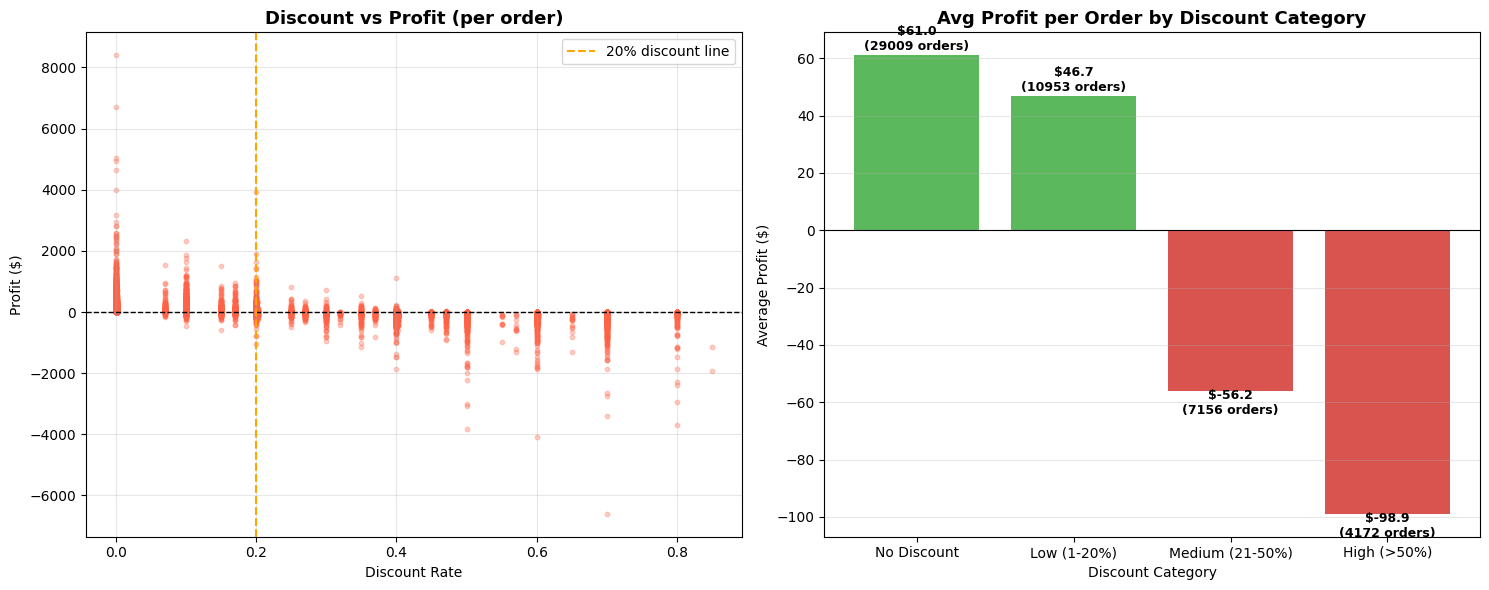

Discount Impact Analysis:
  No Discount: Avg Profit=$61.04 | Orders=29009
  Low (1-20%): Avg Profit=$46.69 | Orders=10953
  Medium (21-50%): Avg Profit=$-56.19 | Orders=7156
  High (>50%): Avg Profit=$-98.89 | Orders=4172


In [12]:
# Discount vs Profit Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1 - Scatter: Discount vs Profit
axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='tomato', s=10)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].axvline(0.2, color='orange', linewidth=1.5, linestyle='--', label='20% discount line')
axes[0].set_title('Discount vs Profit (per order)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Chart 2 - Avg Profit by Discount Category
disc = df.groupby('Discount_Category', observed=True)['Profit'].agg(['mean', 'count']).reset_index()
colors = ['#5cb85c' if x > 0 else '#d9534f' for x in disc['mean']]
bars = axes[1].bar(disc['Discount_Category'], disc['mean'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Profit per Order by Discount Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount Category')
axes[1].set_ylabel('Average Profit ($)')
axes[1].grid(axis='y', alpha=0.3)

# Add labels
for bar, row in zip(bars, disc.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (2 if row.mean >= 0 else -8),
                f'${row.mean:.1f}\n({row.count} orders)',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

# Key numbers
print("Discount Impact Analysis:")
for _, row in disc.iterrows():
    print(f"  {row['Discount_Category']}: Avg Profit=${row['mean']:.2f} | Orders={row['count']}")

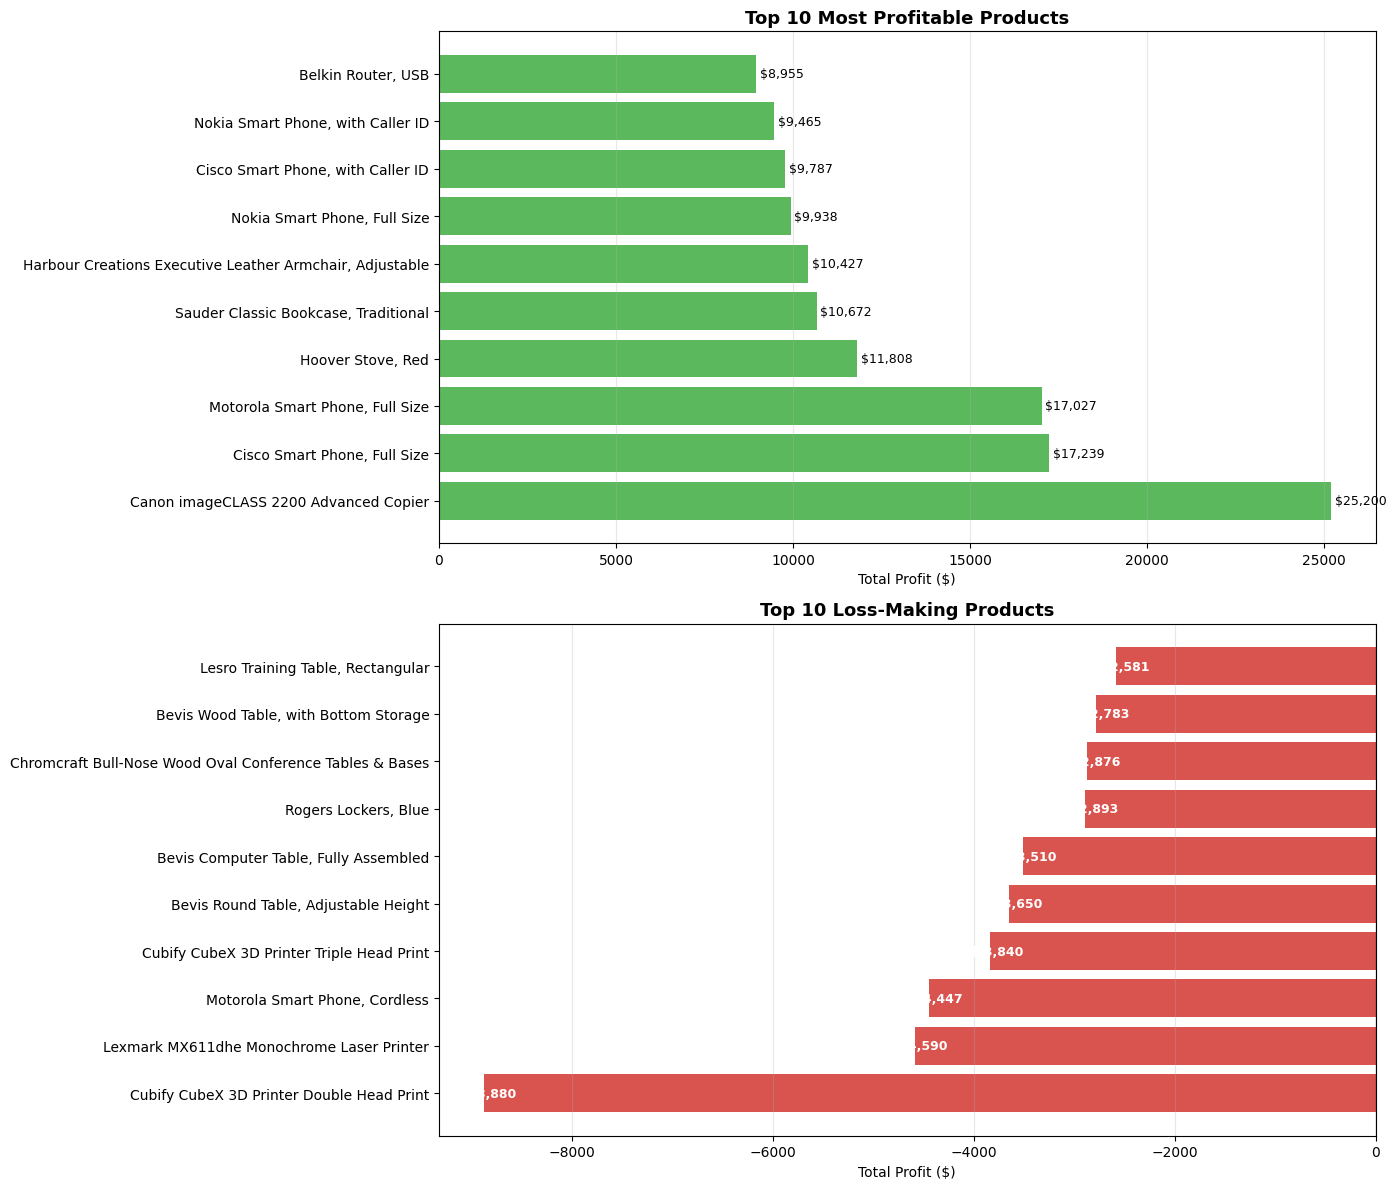

TOP 10 PROFITABLE PRODUCTS:
  Canon imageCLASS 2200 Advanced Copier: $25,200
  Cisco Smart Phone, Full Size: $17,239
  Motorola Smart Phone, Full Size: $17,027
  Hoover Stove, Red: $11,808
  Sauder Classic Bookcase, Traditional: $10,672
  Harbour Creations Executive Leather Armchair, Adju: $10,427
  Nokia Smart Phone, Full Size: $9,938
  Cisco Smart Phone, with Caller ID: $9,787
  Nokia Smart Phone, with Caller ID: $9,465
  Belkin Router, USB: $8,955

TOP 10 LOSS-MAKING PRODUCTS:
  Cubify CubeX 3D Printer Double Head Print: $-8,880
  Lexmark MX611dhe Monochrome Laser Printer: $-4,590
  Motorola Smart Phone, Cordless: $-4,447
  Cubify CubeX 3D Printer Triple Head Print: $-3,840
  Bevis Round Table, Adjustable Height: $-3,650
  Bevis Computer Table, Fully Assembled: $-3,510
  Rogers Lockers, Blue: $-2,893
  Chromcraft Bull-Nose Wood Oval Conference Tables &: $-2,876
  Bevis Wood Table, with Bottom Storage: $-2,783
  Lesro Training Table, Rectangular: $-2,581


In [13]:
# Top 10 Products by Profit
top_products = df.groupby('Product Name')['Profit'].sum().reset_index()
top10 = top_products.sort_values('Profit', ascending=False).head(10)
bottom10 = top_products.sort_values('Profit', ascending=True).head(10)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10 Most Profitable
bars1 = axes[0].barh(top10['Product Name'], top10['Profit'], color='#5cb85c')
axes[0].set_title('Top 10 Most Profitable Products', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars1, top10['Profit']):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=9)

# Top 10 Loss-Making
bars2 = axes[1].barh(bottom10['Product Name'], bottom10['Profit'], color='#d9534f')
axes[1].set_title('Top 10 Loss-Making Products', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, bottom10['Profit']):
    axes[1].text(bar.get_width() - 200, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('top_loss_products.png', dpi=150)
plt.show()

# Key numbers
print("TOP 10 PROFITABLE PRODUCTS:")
for _, row in top10.iterrows():
    print(f"  {row['Product Name'][:50]}: ${row['Profit']:,.0f}")

print("\nTOP 10 LOSS-MAKING PRODUCTS:")
for _, row in bottom10.iterrows():
    print(f"  {row['Product Name'][:50]}: ${row['Profit']:,.0f}")

In [14]:
# Summary stats before export
print("=" * 50)
print("FINAL EDA SUMMARY")
print("=" * 50)
print(f"Total Records:       {len(df):,}")
print(f"Total Revenue:       ${df['Sales'].sum():,.0f}")
print(f"Total Profit:        ${df['Profit'].sum():,.0f}")
print(f"Overall Margin:      {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")
print(f"Total Orders:        {df['Order ID'].nunique():,}")
print(f"Total Products:      {df['Product Name'].nunique():,}")
print(f"Total Countries:     {df['Country'].nunique():,}")
print(f"Date Range:          {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Loss-making orders:  {(df['Profit']<0).sum():,} ({(df['Profit']<0).mean()*100:.1f}%)")
print("=" * 50)

# Export clean CSV for SQL phase
df.to_csv('cleaned_superstore.csv', index=False)
print("\n✅ Clean dataset exported as 'cleaned_superstore.csv'")
print("Python EDA Phase COMPLETE!")

FINAL EDA SUMMARY
Total Records:       51,290
Total Revenue:       $12,642,502
Total Profit:        $1,467,457
Overall Margin:      11.6%
Total Orders:        25,035
Total Products:      3,788
Total Countries:     147
Date Range:          2011-01-01 to 2014-12-31
Loss-making orders:  12,544 (24.5%)

✅ Clean dataset exported as 'cleaned_superstore.csv'
Python EDA Phase COMPLETE!


In [17]:
import pandas as pd
import csv

# Reload clean data
df = pd.read_csv('cleaned_superstore.csv')

# Check shape
print("Shape:", df.shape)
print("Columns:", len(df.columns))

# Clean ALL text columns thoroughly
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    df[col] = df[col].astype(str)\
                     .str.replace('"', '', regex=False)\
                     .str.replace("'", '', regex=False)\
                     .str.replace(',', ' ', regex=False)\
                     .str.replace('\n', ' ', regex=False)\
                     .str.replace('\r', ' ', regex=False)\
                     .str.strip()

# Export using pipe | as delimiter (avoids comma conflicts)
df.to_csv('superstore_pipe.csv',
          index=False,
          encoding='utf-8',
          sep='|',
          quoting=csv.QUOTE_NONE,
          escapechar='\\')

print(f"\n✅ Done! Rows: {len(df):,}")
print("Download 'superstore_pipe.csv' from Colab files panel")

Shape: (51290, 30)
Columns: 30

✅ Done! Rows: 51,290
Download 'superstore_pipe.csv' from Colab files panel
